# Evaluating FAIRness of biodiversity resources with the FAIR-Checker API

## Aim 
The goal of this notebook is to automate the FAIR assesment of mutliple Biodiversity specific resources DOIs through the [FAIR-Checker tool](https://fair-checker.france-bioinformatique.fr). 
All resulst are stored in a matrix and serialized into a CSV file. Scores can be interpreted as follows: 
 - 0 -> `failure`
 - 1 -> `weak` assesment
 - 2 -> `strong` assesment

To run this notebook you just need the `requests` and `pandas` python libraries. 

The FAIR-Checker API is better described at https://fair-checker.france-bioinformatique.fr/swagger 

Please report any issue at https://github.com/IFB-ElixirFr/fair-checker/issues or contact alban.gaignard@univ-nantes.fr. 

In [1]:
import time
import requests
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

## Input dataset

In [2]:
URLs = [
    "https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9",
    "https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml",
    "https://boldsystems.org/record/CHOLH011-12",
    "https://bench.boldsystems.org/index.php/datapackages/Latest",
    "https://dataregistry.lteritalia.it/catalogue/#/document/171",
    "https://doi.org/10.3535/ZVR-CRA-1Y1?noredirect",

    "https://www.ebi.ac.uk/ena/browser/view/SAMEA112797446",
    "https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446",
    "https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446.ldjson",

    "https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_963981305.1/",
    "https://www.ncbi.nlm.nih.gov/biosample/SAMEA112797446/",

    "https://portal.erga-biodiversity.eu/data_portal/878968",
    "https://portal.erga-biodiversity.eu/organism/SAMEA112797446", 
    
    "https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e", 
    "https://doi.org/10.15468/aomfnb", 
    
    "https://disscover.dissco.eu/ds/10.3535/J0R-CD8-SH5", 
    "https://disscover.dissco.eu/api/digital-specimen/v1/10.3535/KJE-E3A-Q80", 
    "https://jacq.org/detail/1651282" 
]

URLs


['https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9',
 'https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml',
 'https://boldsystems.org/record/CHOLH011-12',
 'https://bench.boldsystems.org/index.php/datapackages/Latest',
 'https://dataregistry.lteritalia.it/catalogue/#/document/171',
 'https://doi.org/10.3535/ZVR-CRA-1Y1?noredirect',
 'https://www.ebi.ac.uk/ena/browser/view/SAMEA112797446',
 'https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446',
 'https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446.ldjson',
 'https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_963981305.1/',
 'https://www.ncbi.nlm.nih.gov/biosample/SAMEA112797446/',
 'https://portal.erga-biodiversity.eu/data_portal/878968',
 'https://portal.erga-biodiversity.eu/organism/SAMEA112797446',
 'https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e',
 'https://doi.org/10.15468/aomfnb',


In [3]:
FC_all_metrics_url = "https://fair-checker.france-bioinformatique.fr/api/check/legacy/metrics_all"

## FAIR assesment over all inputs 

In [4]:
from json import JSONDecodeError
import pandas as pd
import time
import requests
import json
from tqdm.notebook import tqdm

df = pd.DataFrame()
rows = []

for u in tqdm(URLs):
    start = time.time()
    res = requests.get(url=FC_all_metrics_url, params={"url": u})
    eval_in_sec = time.time() - start
    
    try: 
        evaluations = res.json()
        row = {"URL": u}
    
        # iterating over all evaluation results
        for e in evaluations:
            row[e["metric"]] = int(e["score"])
        # row["duration (s)"] = round(eval_in_sec, 2)
        print(row)
        rows.append(row)
    except JSONDecodeError as error:
        print("Cannot get FAIR assesment for "+u)
        

  0%|          | 0/18 [00:00<?, ?it/s]

{'URL': 'https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9', 'F1A': 2, 'F1B': 0, 'F2A': 0, 'F2B': 0, 'A1.1': 2, 'A1.2': 0, 'I1': 0, 'I2': 0, 'I3': 0, 'R1.1': 0, 'R1.2': 0, 'R1.3': 0}
{'URL': 'https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml', 'F1A': 2, 'F1B': 0, 'F2A': 0, 'F2B': 0, 'A1.1': 2, 'A1.2': 0, 'I1': 0, 'I2': 0, 'I3': 0, 'R1.1': 0, 'R1.2': 0, 'R1.3': 0}
{'URL': 'https://boldsystems.org/record/CHOLH011-12', 'F1A': 0, 'F1B': 0, 'F2A': 1, 'F2B': 0, 'A1.1': 0, 'A1.2': 0, 'I1': 1, 'I2': 0, 'I3': 0, 'R1.1': 0, 'R1.2': 0, 'R1.3': 0}
{'URL': 'https://bench.boldsystems.org/index.php/datapackages/Latest', 'F1A': 2, 'F1B': 0, 'F2A': 0, 'F2B': 0, 'A1.1': 2, 'A1.2': 0, 'I1': 0, 'I2': 0, 'I3': 0, 'R1.1': 0, 'R1.2': 0, 'R1.3': 0}
{'URL': 'https://dataregistry.lteritalia.it/catalogue/#/document/171', 'F1A': 2, 'F1B': 0, 'F2A': 1, 'F2B': 2, 'A1.1': 2, 'A1.2': 0, 'I1':

## Evaluation matrix

In [5]:
from IPython.display import display, Markdown
df = pd.DataFrame.from_records(rows)

df["F_score"] = df.apply(
    lambda row: round((row["F1A"] + row["F1B"] + row["F2A"] + row["F2B"]) * 100 / 8, 1),
    axis=1,
)
df["A_score"] = df.apply(
    lambda row: round((row["A1.1"] + row["A1.2"]) * 100 / 4, 1), axis=1
)
df["I_score"] = df.apply(
    lambda row: round((row["I1"] + row["I2"] + row["I3"]) * 100 / 6, 1), axis=1
)
df["R_score"] = df.apply(
    lambda row: round((row["R1.1"] + row["R1.2"] + row["R1.3"]) * 100 / 6, 1), axis=1
)
# df['FAIR_score'] = df.apply(lambda row: round((row["F_score"] + row["A_score"] + row["I_score"] + row["R_score"])/4, 1), axis = 1)
df["FAIR_score"] = df.apply(
    lambda row: round(
        (
            row["F1A"]
            + row["F1B"]
            + row["F2A"]
            + row["F2B"]
            + row["A1.1"]
            + row["A1.2"]
            + row["I1"]
            + row["I2"]
            + row["I3"]
            + row["R1.1"]
            + row["R1.2"]
            + row["R1.3"]
        )
        * 100
        / 24,
        1,
    ),
    axis=1,
)

df.to_csv("biodiv-fc_evals-2026.csv")

md = df.to_markdown()
display(Markdown(md))

|    | URL                                                                                                                   |   F1A |   F1B |   F2A |   F2B |   A1.1 |   A1.2 |   I1 |   I2 |   I3 |   R1.1 |   R1.2 |   R1.3 |   F_score |   A_score |   I_score |   R_score |   FAIR_score |
|---:|:----------------------------------------------------------------------------------------------------------------------|------:|------:|------:|------:|-------:|-------:|-----:|-----:|-----:|-------:|-------:|-------:|----------:|----------:|----------:|----------:|-------------:|
|  0 | https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9          |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
|  1 | https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
|  2 | https://boldsystems.org/record/CHOLH011-12                                                                            |     0 |     0 |     1 |     0 |      0 |      0 |    1 |    0 |    0 |      0 |      0 |      0 |      12.5 |         0 |      16.7 |       0   |          8.3 |
|  3 | https://bench.boldsystems.org/index.php/datapackages/Latest                                                           |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
|  4 | https://dataregistry.lteritalia.it/catalogue/#/document/171                                                           |     2 |     0 |     1 |     2 |      2 |      0 |    1 |    2 |    0 |      0 |      0 |      2 |      62.5 |        50 |      50   |      33.3 |         50   |
|  5 | https://doi.org/10.3535/ZVR-CRA-1Y1?noredirect                                                                        |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
|  6 | https://www.ebi.ac.uk/ena/browser/view/SAMEA112797446                                                                 |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
|  7 | https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446                                                               |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
|  8 | https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446.ldjson                                                        |     2 |     2 |     1 |     2 |      2 |      0 |    1 |    1 |    0 |      0 |      0 |      1 |      87.5 |        50 |      33.3 |      16.7 |         50   |
|  9 | https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_963981305.1/                                                         |     2 |     0 |     1 |     2 |      2 |      0 |    1 |    2 |    0 |      0 |      0 |      2 |      62.5 |        50 |      50   |      33.3 |         50   |
| 10 | https://www.ncbi.nlm.nih.gov/biosample/SAMEA112797446/                                                                |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
| 11 | https://portal.erga-biodiversity.eu/data_portal/878968                                                                |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
| 12 | https://portal.erga-biodiversity.eu/organism/SAMEA112797446                                                           |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
| 13 | https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e                                                     |     0 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |       0   |        50 |       0   |       0   |          8.3 |
| 14 | https://doi.org/10.15468/aomfnb                                                                                       |     0 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |       0   |        50 |       0   |       0   |          8.3 |
| 15 | https://disscover.dissco.eu/ds/10.3535/J0R-CD8-SH5                                                                    |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
| 16 | https://disscover.dissco.eu/api/digital-specimen/v1/10.3535/KJE-E3A-Q80                                               |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |
| 17 | https://jacq.org/detail/1651282                                                                                       |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |      25   |        50 |       0   |       0   |         16.7 |

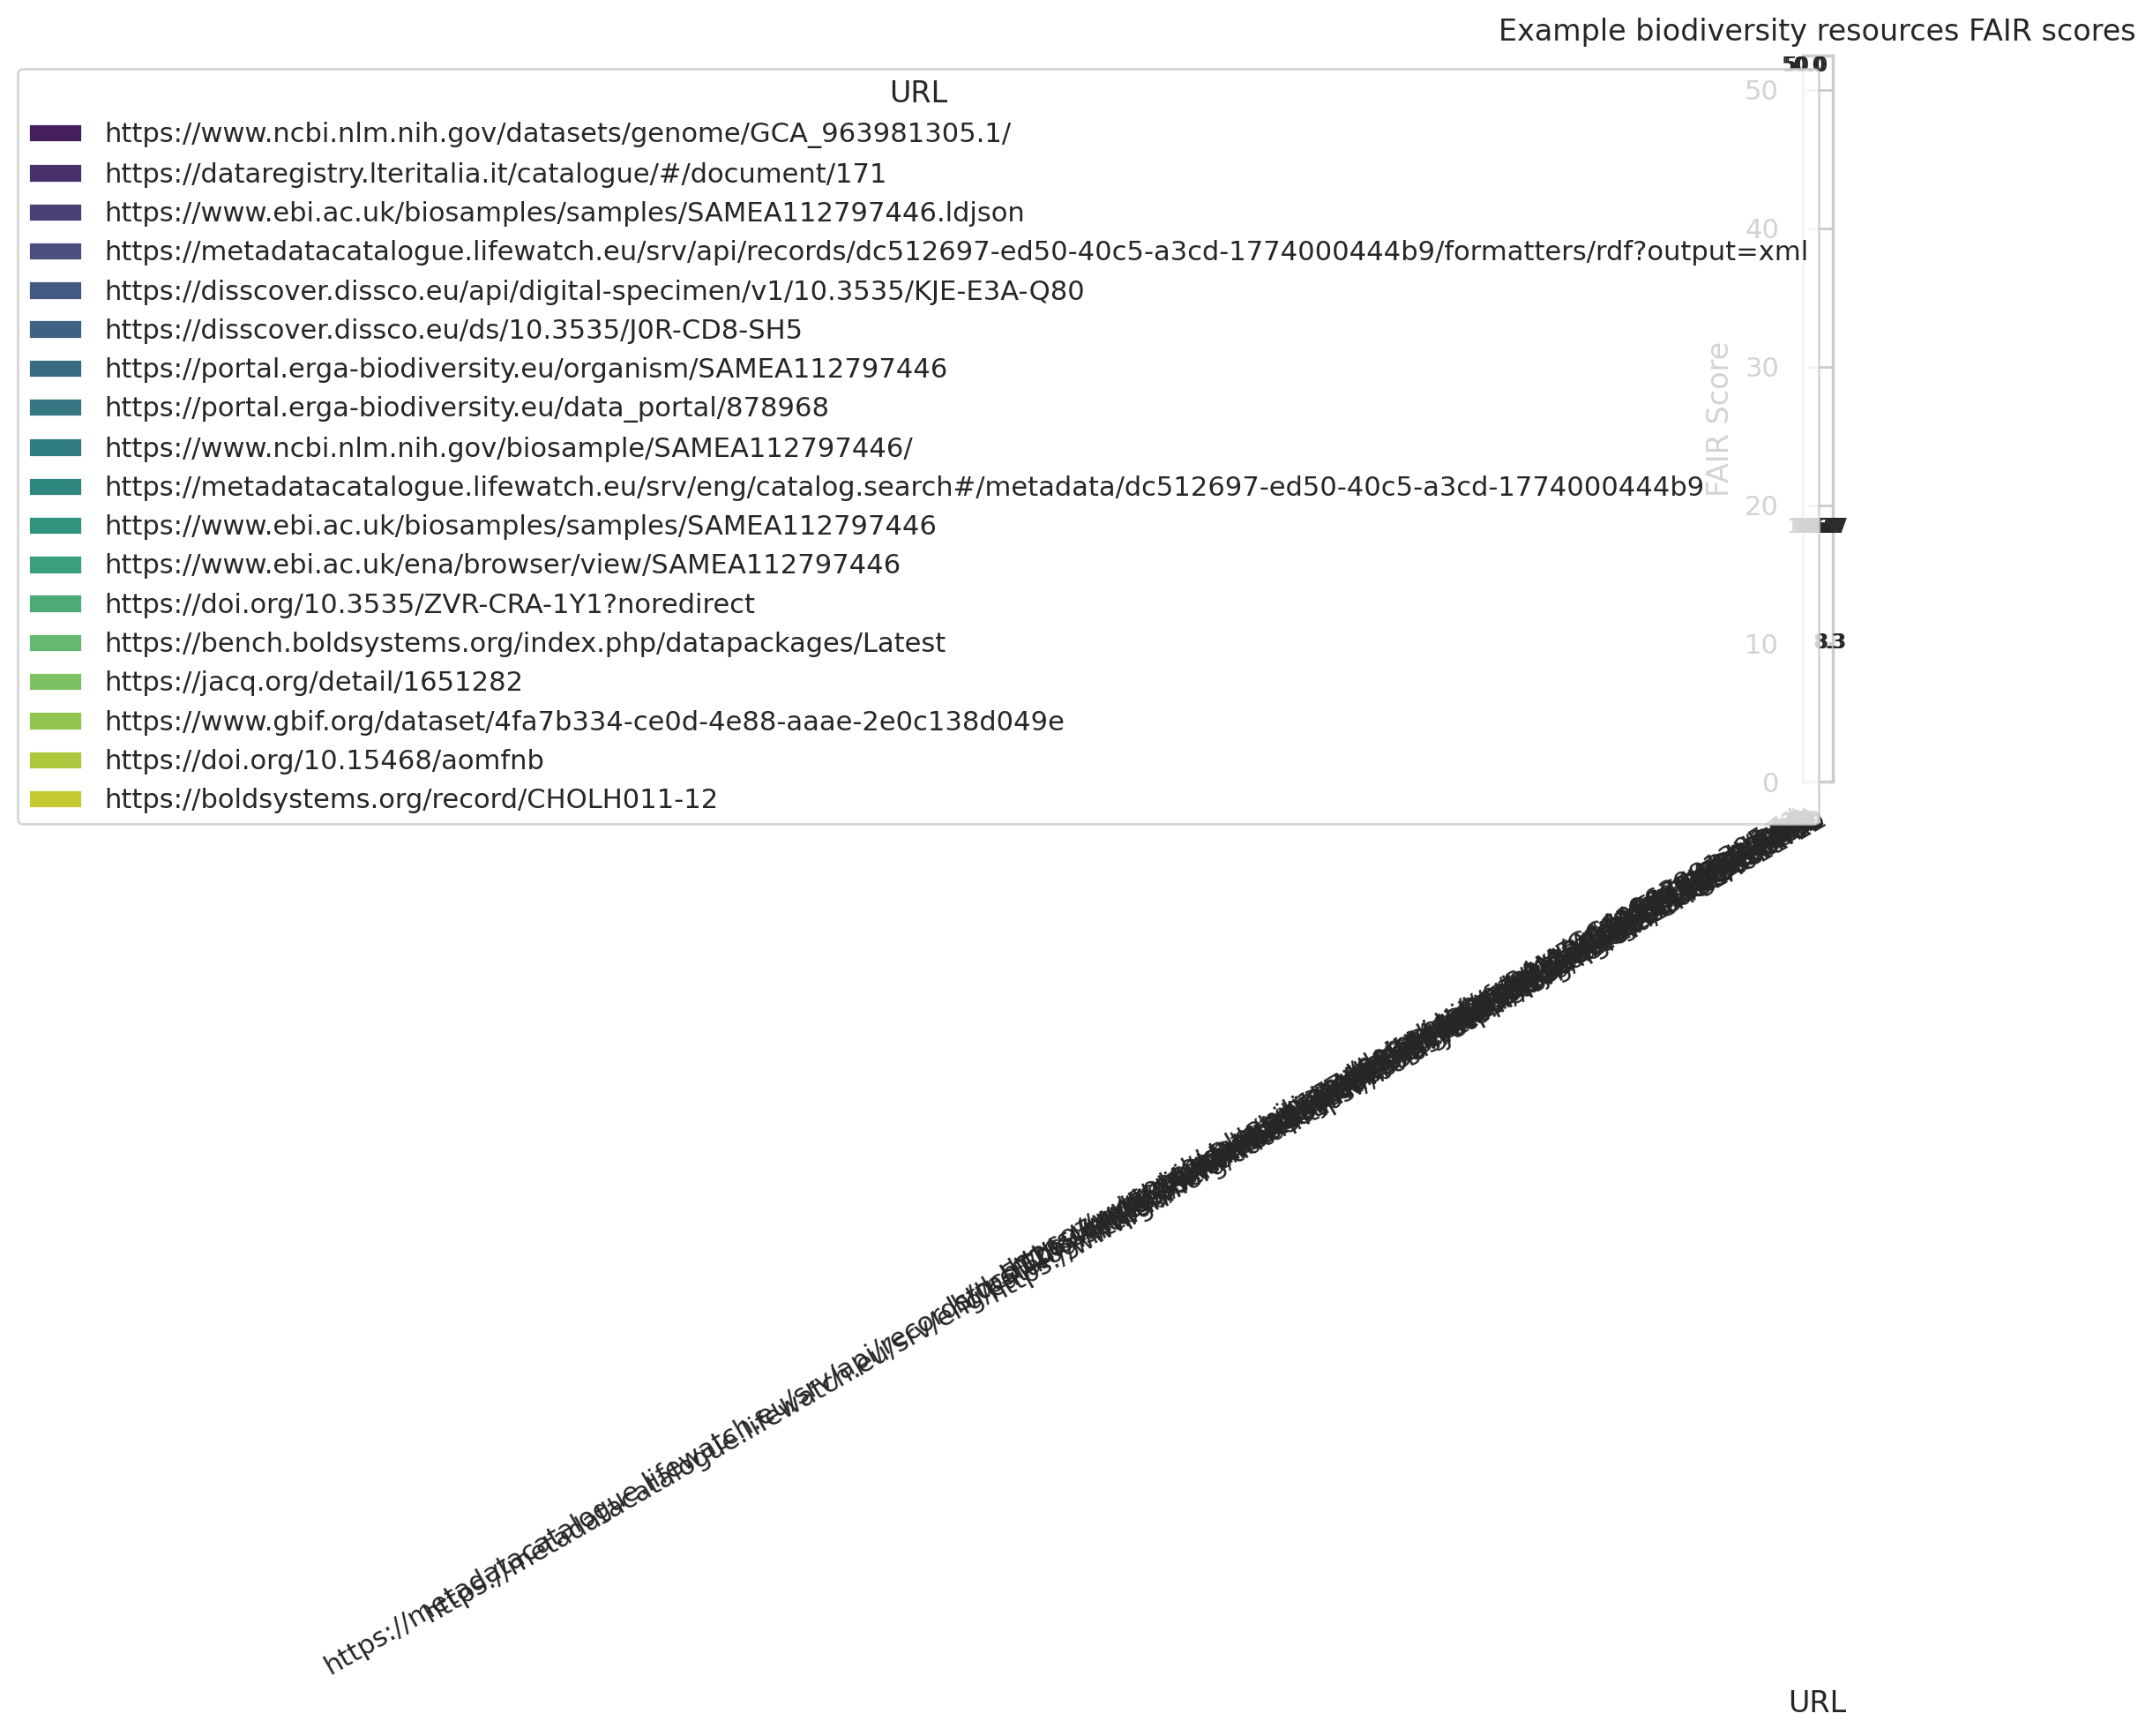

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv("biodiv-fc_evals-2026.csv")

# plot with seaborn a bar plot for all FAIR scores of the DOIs
plt.figure(figsize=(10, 10))
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 8

# sort the dataframe by FAIR score
df = df.sort_values(by="FAIR_score", ascending=False, ignore_index=True)

sns.set_theme(style="whitegrid")
sns.barplot(data=df, x="URL", y="FAIR_score", hue="URL", palette="viridis", legend=False)

# annotate the bars with the FAIR score
for index, row in df.iterrows():
    plt.text(
        index,
        row["FAIR_score"] + 1,
        str(row["FAIR_score"]),
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.xticks(rotation=30, ha="right")
plt.title(f"Example biodiversity resources FAIR scores")
plt.xlabel("URL")
plt.ylabel("FAIR Score")
plt.tight_layout()


plt.savefig("biodiv_fair_scores.png", dpi=300)
plt.savefig("biodiv_fair_scores.pdf", dpi=300)
plt.show()